In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF 
import xarray as xr
import matplotlib.pyplot as plt

from renewable_data_load import *
from plotting_config import model_colors, gwl_colors, model_markers

import time

# Load matplotlib style sheet for consistent formatting
plt.style.use('../../renewable_analysis.mplstyle')


In [ ]:
# Model colors, GWL colors, and markers are imported from plotting_config module
# Style sheet settings (font sizes, grid, etc.) are loaded from renewable_analysis.mplstyle


# Daily peak demand

In [4]:
# load and merge data from each region
peak_load_directory = "../../data/demand/DailyPeaks/"
# get list of csv files in directory
import os
csv_files = [f for f in os.listdir(peak_load_directory) if f.endswith('.csv')]

region_datasets = []  # Collect datasets with region names

for file in csv_files:
    region_name = file.split('_')[0]  # assuming the format is REGION_daily_peaks_reference_2025.csv
    df = pd.read_csv(os.path.join(peak_load_directory, file))
    df = df.rename(columns={'Date': 'time'})
    df.set_index('time', inplace=True)
    ds = df.to_xarray()
    
    # Add region name as coordinate
    ds = ds.expand_dims({'region': [region_name]})
    region_datasets.append(ds)

# Concatenate all regions with their names
peak_demand_ds = xr.concat(region_datasets, dim='region')

peak_demand_ds['time'] = pd.to_datetime(peak_demand_ds.time.values)
peak_demand_ds = peak_demand_ds.convert_calendar("noleap")

In [5]:
peak_demand_ds = peak_demand_ds.rename({'EC_EARTH3':'ec-earth3',
                                        'MIROC6':'miroc6',
                                        'MPI_ESM1_2_HR':'mpi-esm1-2-hr',
                                        'TAIESM1':'taiesm1'})

In [6]:
# Create rolling window

reference_gwl = 0.8
future_gwl = 2.0
gwls = [reference_gwl, future_gwl]

regional_medians = {gwl: {} for gwl in gwls}

for gwl in gwls:
    for simulation in peak_demand_ds.data_vars:
        peak_demand_da = peak_demand_ds[simulation]

        print(f"Calculating drought mask for GWL: {gwl}°C")
        # Get bounds for GWL period
        WRF_sim_name = sim_name_dict[simulation]
        model = WRF_sim_name.split("_")[1]
        ensemble_member = WRF_sim_name.split("_")[2]
        start_year, end_year = get_gwl_crossing_period(model, ensemble_member, gwl)

        peak_demand_da = peak_demand_da.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))

        test_window = peak_demand_da

        # Add dayofyear and year coordinates
        test_window = test_window.assign_coords({
            "dayofyear": test_window.time.dt.dayofyear,
            "year": test_window.time.dt.year
        })

        # Reshape time dimension to separate dayofyear and year
        test_window = test_window.drop_vars("time").set_index(time=['dayofyear', 'year']).unstack()

        # Compute 50th percentile across samples for each day-of-year
        percentile_50 = test_window.quantile(0.5, dim='year')

        print(f"Threshold shape: {percentile_50.dims}")

        #percentile_50.to_netcdf(f'../../data/thresholds/demand_WECC_regions_{simulation}_{gwl}C_90th_pctile.nc')

        regional_medians[gwl][simulation] = percentile_50

Calculating drought mask for GWL: 0.8°C
Threshold shape: ('region', 'dayofyear')
Calculating drought mask for GWL: 0.8°C
Threshold shape: ('region', 'dayofyear')
Calculating drought mask for GWL: 0.8°C
Threshold shape: ('region', 'dayofyear')
Calculating drought mask for GWL: 0.8°C
Threshold shape: ('region', 'dayofyear')
Calculating drought mask for GWL: 2.0°C
Threshold shape: ('region', 'dayofyear')
Calculating drought mask for GWL: 2.0°C
Threshold shape: ('region', 'dayofyear')
Calculating drought mask for GWL: 2.0°C
Threshold shape: ('region', 'dayofyear')
Calculating drought mask for GWL: 2.0°C
Threshold shape: ('region', 'dayofyear')


In [28]:
regions = ['PGE', 'LDWP', 'SDGE', 'SCE', 'IID', 'NCNC', 'WECC-MTN', 'WECC-SW','WECC-NW']

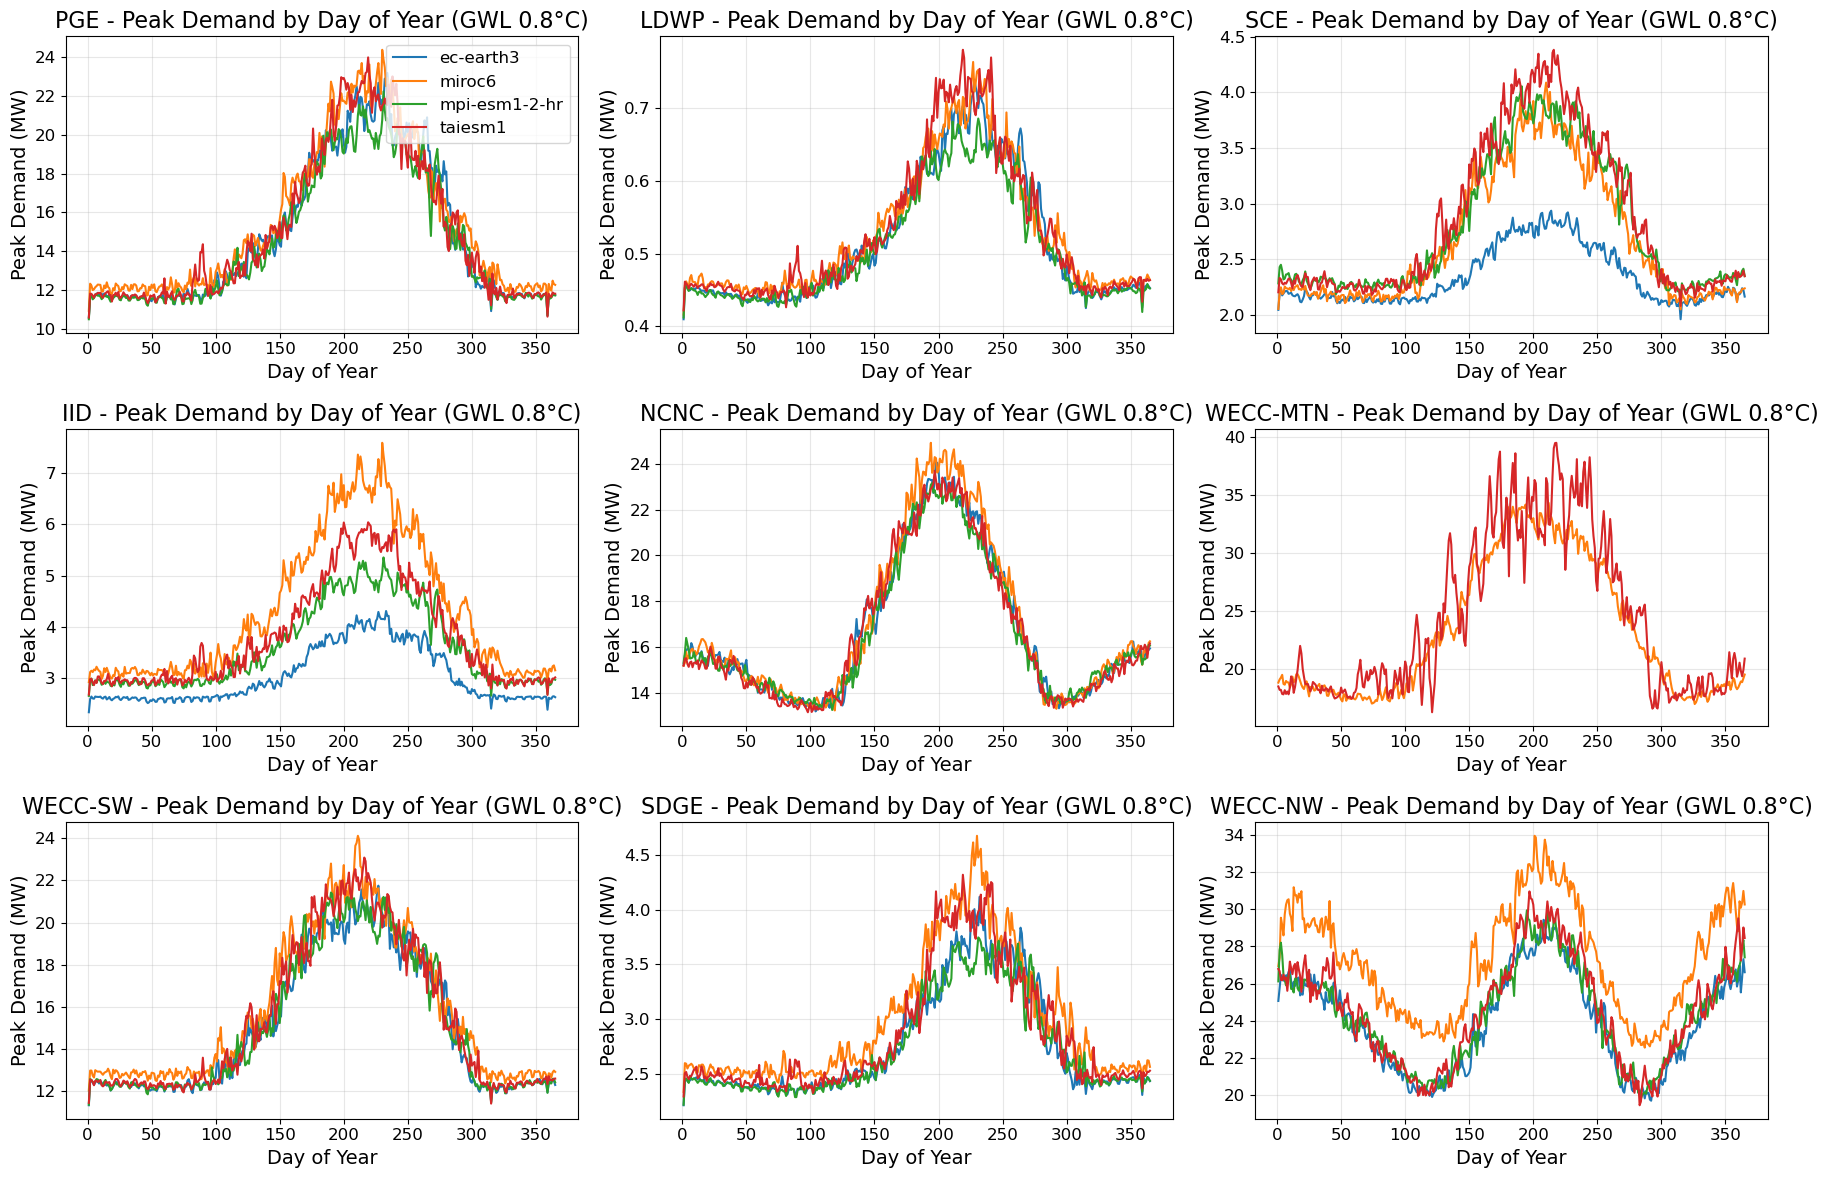

In [ ]:
# Plot each model run individually for 0.8 GWL
gwl_to_plot = reference_gwl
gwl_medians = regional_medians[gwl_to_plot]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for model in gwl_medians.keys():
    thresh = gwl_medians[model]
    for i, var in enumerate(regions):
        thresh.isel(region=i).plot(ax=axes[i], label=model, color=model_colors[model])
        axes[i].set_xlabel("Day of Year")
        axes[i].set_ylabel("Peak Demand (MW)")
        axes[i].set_title(f"{var} - Peak Demand by Day of Year (GWL {gwl_to_plot}°C)")
        axes[i].grid(True, alpha=0.3)

axes[0].legend(loc="upper right")
plt.tight_layout()

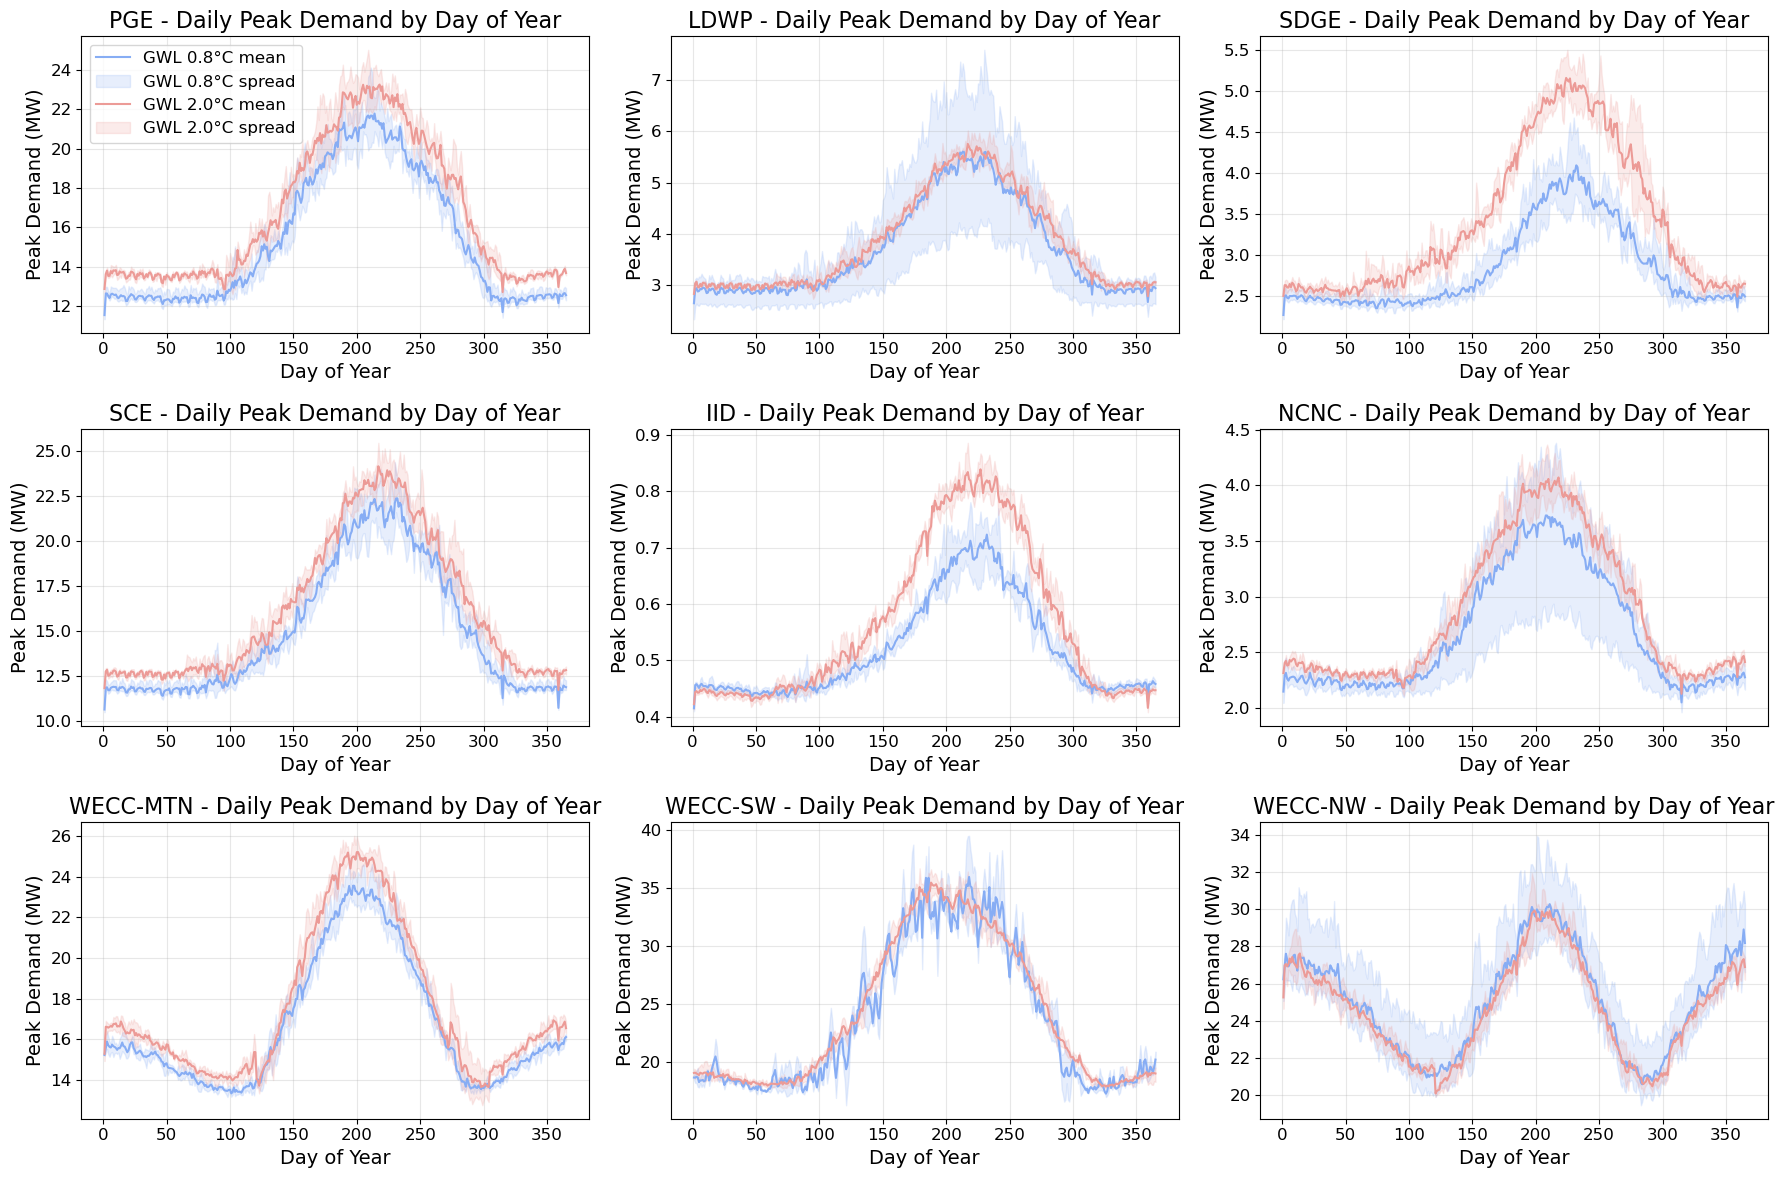

In [50]:
# Plot multi-model mean with model spread shading for both GWLs on one figure
gwls_to_plot = [reference_gwl, future_gwl]
gwl_colors = {reference_gwl: (0.53003, 0.67969, 0.95735), future_gwl: [0.92437, 0.60747, 0.59309]}

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for gwl_to_plot in gwls_to_plot:
    gwl_medians = regional_medians[gwl_to_plot]
    models = list(gwl_medians.keys())
    stacked = xr.concat([gwl_medians[m] for m in models], dim="model").assign_coords(model=models)
    mean_thresh = stacked.mean("model")
    min_thresh = stacked.min("model")
    max_thresh = stacked.max("model")
    color = gwl_colors.get(gwl_to_plot, None)

    for i, var in enumerate(regions):
        x = mean_thresh.dayofyear.values
        y_mean = mean_thresh.sel(region=var).values
        y_min = min_thresh.sel(region=var).values
        y_max = max_thresh.sel(region=var).values
        axes[i].plot(x, y_mean, label=f"GWL {gwl_to_plot}°C mean", color=color)
        axes[i].fill_between(x, y_min, y_max, alpha=0.2, color=color, label=f"GWL {gwl_to_plot}°C spread")
        axes[i].set_xlabel("Day of Year")
        axes[i].set_ylabel("Peak Demand (MW)")
        axes[i].set_title(f"{var} - Daily Peak Demand by Day of Year")
        axes[i].grid(True, alpha=0.3)

axes[0].legend(loc="upper left", ncol=1)
plt.tight_layout()

plt.savefig('figures/peak_daily_regional_demand.png', dpi=400, bbox_inches='tight')

# Number of high demand days

Loading mask for ec-earth3...
Loading mask for miroc6...
Loading mask for mpi-esm1-2-hr...
Loading mask for taiesm1...


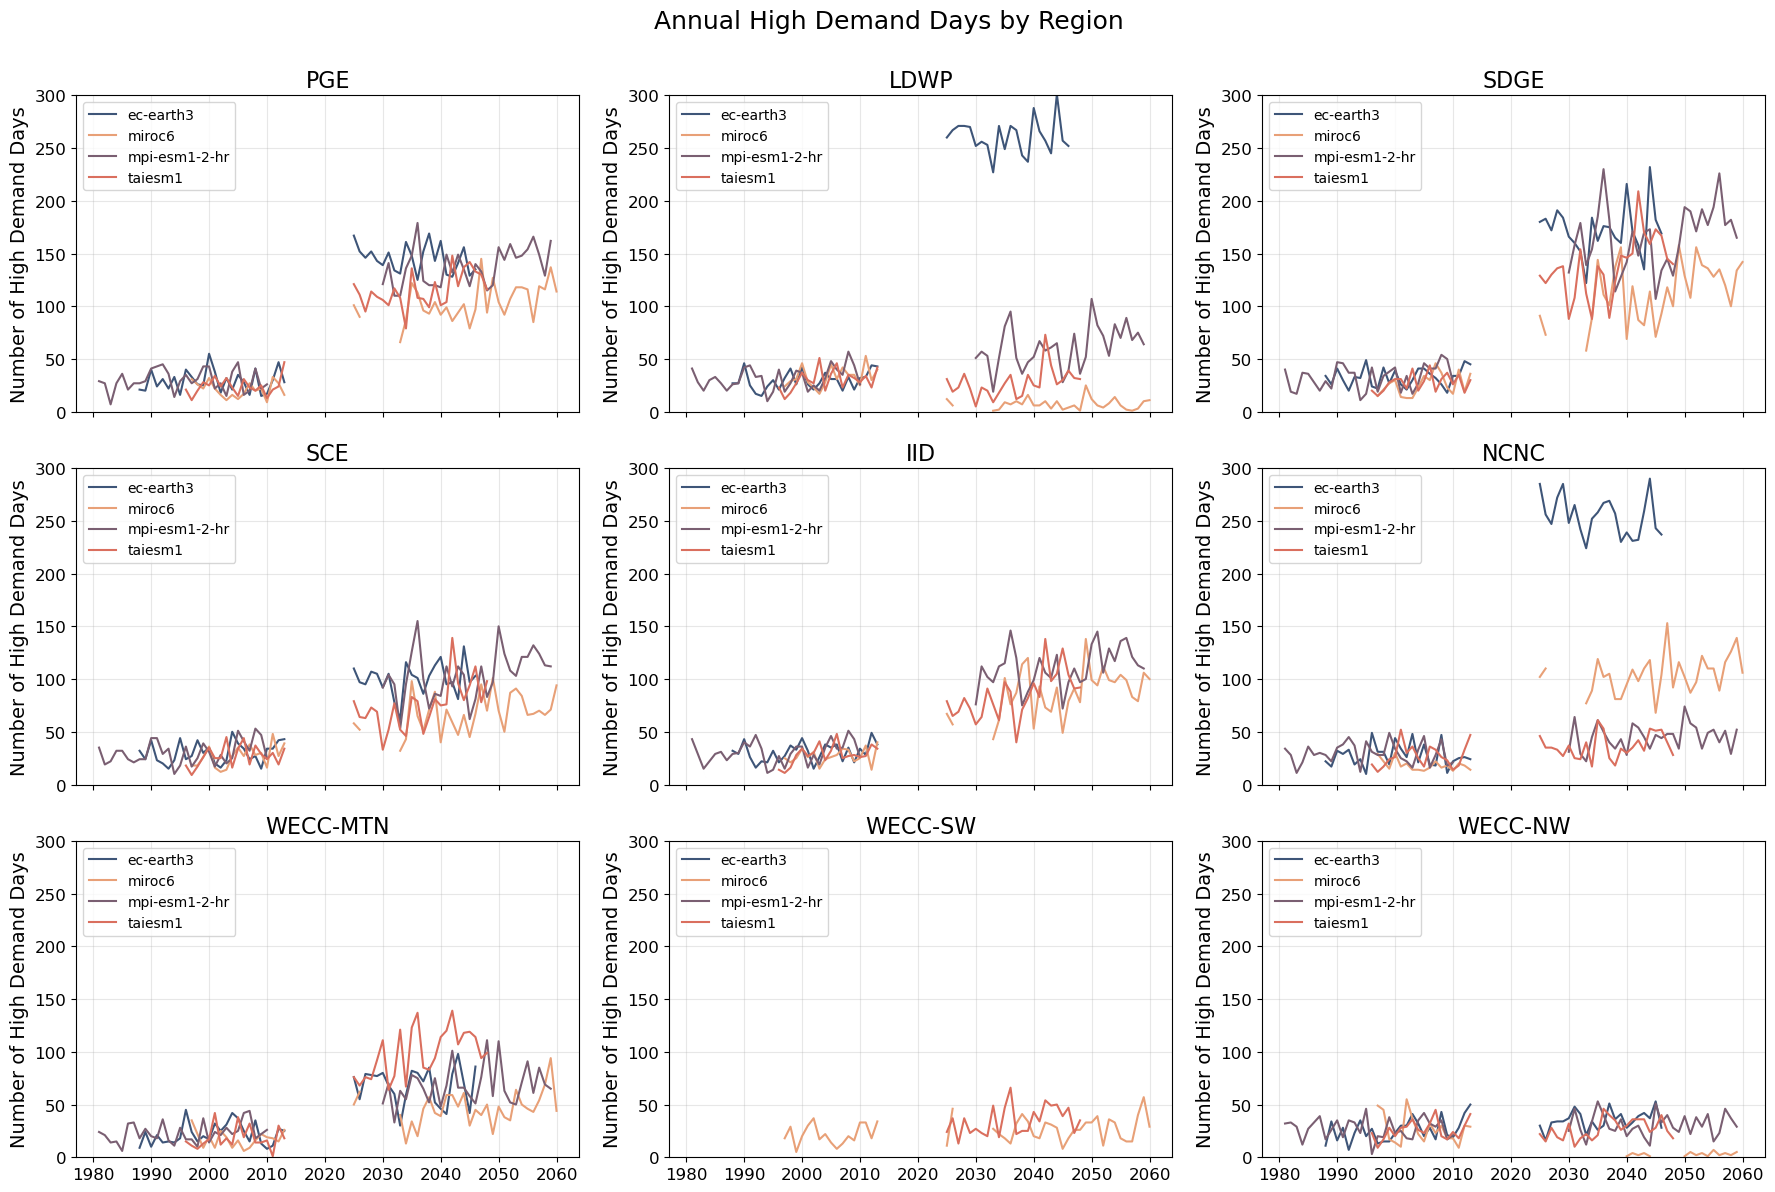

In [44]:
# Load high demand masks from zarr files and combine into a dataset
# Note: We combine reference and future GWL periods, removing any temporal overlap
reference_gwl = 0.8
future_gwl = 2.0

# Dictionary to store masks for each simulation
highdemand_mask_dict = {}

for simulation in peak_demand_ds.data_vars:
    print(f"Loading mask for {simulation}...")
    
    # Load reference and future masks
    ref_mask_file = f"../../data/drought_masks/demand_byregion_{simulation}_gwl{reference_gwl}_demand_mask_only.zarr"
    fut_mask_file = f"../../data/drought_masks/demand_byregion_{simulation}_gwl{future_gwl}_demand_mask_only.zarr"
    
    ref_mask_ds = xr.open_zarr(ref_mask_file)
    fut_mask_ds = xr.open_zarr(fut_mask_file)
    
    # Extract DataArrays
    ref_mask = ref_mask_ds[list(ref_mask_ds.data_vars)[0]]
    fut_mask = fut_mask_ds[list(fut_mask_ds.data_vars)[0]]
    
    # Drop any non-essential coordinates that might conflict during concatenation
    coords_to_drop = [c for c in ref_mask.coords if c not in ['time', 'region']]
    if coords_to_drop:
        ref_mask = ref_mask.drop_vars(coords_to_drop)
        fut_mask = fut_mask.drop_vars(coords_to_drop)
    
    # Combine reference and future periods, handling potential time overlap
    # Concatenate and then drop duplicate times (keeping first occurrence)
    combined_mask = xr.concat([ref_mask, fut_mask], dim='time')
    
    # Sort by time and remove duplicates
    combined_mask = combined_mask.sortby('time')
    _, unique_indices = np.unique(combined_mask.time.values, return_index=True)
    combined_mask = combined_mask.isel(time=sorted(unique_indices))
    
    highdemand_mask_dict[simulation] = combined_mask

# Convert dictionary to Dataset
highdemand_mask = xr.Dataset(highdemand_mask_dict)

# Restore proper region names
region_names = peak_demand_ds.region.values
highdemand_mask['region'] = region_names

# Calculate annual sum of high demand days for each region and model
highdemand_mask_annual = highdemand_mask.copy()
highdemand_mask_annual['year'] = highdemand_mask_annual.time.dt.year

# Group by year and sum for each region and model
annual_counts = highdemand_mask_annual.groupby('year').sum(dim='time')

# Create 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()
fig.suptitle('Annual High Demand Days by Region', fontsize=18, y=0.995)

# Plot each region
for i, region in enumerate(regions):
    ax = axes[i]
    region_data = annual_counts.sel(region=region)
    
    # Plot each model for this region
    for var in region_data.data_vars:
        (region_data[var].where(region_data[var] > 0)).plot(ax=ax, label=var, color=model_colors[var])
    
    ax.set_xlabel('')
    ax.set_ylabel('Number of High Demand Days')
    ax.set_title(f'{region}')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0,300)

plt.tight_layout()
plt.savefig('figures/annual_high_demand_days.png', dpi=400, bbox_inches='tight')
plt.show()

## Quarterly Change in High Demand Days (by GWL)

Calculate the change in average quarterly high demand days from reference (0.8°C) to future (2.0°C) GWL periods.

In [21]:
# Set GWL periods
reference_gwl = 0.8
future_gwl = 2.0

# Dictionary to store quarterly averages for each model, region, and GWL
seasonal_changes = {}

# Get correct region names from the peak demand dataset
region_names = peak_demand_ds.region.values

for simulation in peak_demand_ds.data_vars:
    print(f"Processing {simulation}...")
    
    # Load both reference and future period masks from saved zarr files
    ref_mask_file = f"../../data/drought_masks/demand_byregion_{simulation}_gwl{reference_gwl}_demand_mask_only.zarr"
    mask_ref_ds = xr.open_zarr(ref_mask_file)
    
    fut_mask_file = f"../../data/drought_masks/demand_byregion_{simulation}_gwl{future_gwl}_demand_mask_only.zarr"
    mask_fut_ds = xr.open_zarr(fut_mask_file)
    
    # Extract DataArray from Dataset (zarr files are loaded as Datasets)
    mask_ref = mask_ref_ds[list(mask_ref_ds.data_vars)[0]]
    mask_fut = mask_fut_ds[list(mask_fut_ds.data_vars)[0]]
    
    # Restore proper region names (in case zarr files have integer indices)
    mask_ref['region'] = region_names
    mask_fut['region'] = region_names
    
    # Add quarter coordinate (JFM, AMJ, JAS, OND)
    # Map months to quarters: 1-3 -> JFM, 4-6 -> AMJ, 7-9 -> JAS, 10-12 -> OND
    def assign_quarter(month):
        if month in [1, 2, 3]:
            return 'JFM'
        elif month in [4, 5, 6]:
            return 'AMJ'
        elif month in [7, 8, 9]:
            return 'JAS'
        else:
            return 'OND'
    
    mask_ref['quarter'] = xr.apply_ufunc(
        assign_quarter, mask_ref.time.dt.month,
        vectorize=True, dask='allowed'
    )
    mask_fut['quarter'] = xr.apply_ufunc(
        assign_quarter, mask_fut.time.dt.month,
        vectorize=True, dask='allowed'
    )
    
    # For each quarter: sum high demand days per quarter per year, then average across years
    # First group by year and quarter to get quarterly sums per year
    ref_seasonal = mask_ref.groupby('time.year').apply(
        lambda x: x.groupby('quarter').sum(dim='time')
    )
    fut_seasonal = mask_fut.groupby('time.year').apply(
        lambda x: x.groupby('quarter').sum(dim='time')
    )
    
    # Average across years to get mean quarterly high demand days
    ref_seasonal_mean = ref_seasonal.mean(dim='year')
    fut_seasonal_mean = fut_seasonal.mean(dim='year')
    
    # Calculate change (future - reference)
    seasonal_change = fut_seasonal_mean - ref_seasonal_mean
    
    # Filter out invalid data: if reference OR future period has all zeros, set to NaN
    # Check if total high demand days across all quarters is zero
    ref_total = mask_ref.sum(dim='time')
    fut_total = mask_fut.sum(dim='time')
    
    # For each region, if either reference or future has zero total high demand days, set all quarters to NaN
    for region in seasonal_change.region.values:
        if ref_total.sel(region=region).values == 0 or fut_total.sel(region=region).values == 0:
            print(f"  Warning: {region} has all zeros in reference or future period - setting to NaN")
            seasonal_change.loc[dict(region=region)] = np.nan
    
    seasonal_changes[simulation] = seasonal_change

Processing ec-earth3...
Processing miroc6...
Processing mpi-esm1-2-hr...
Processing taiesm1...


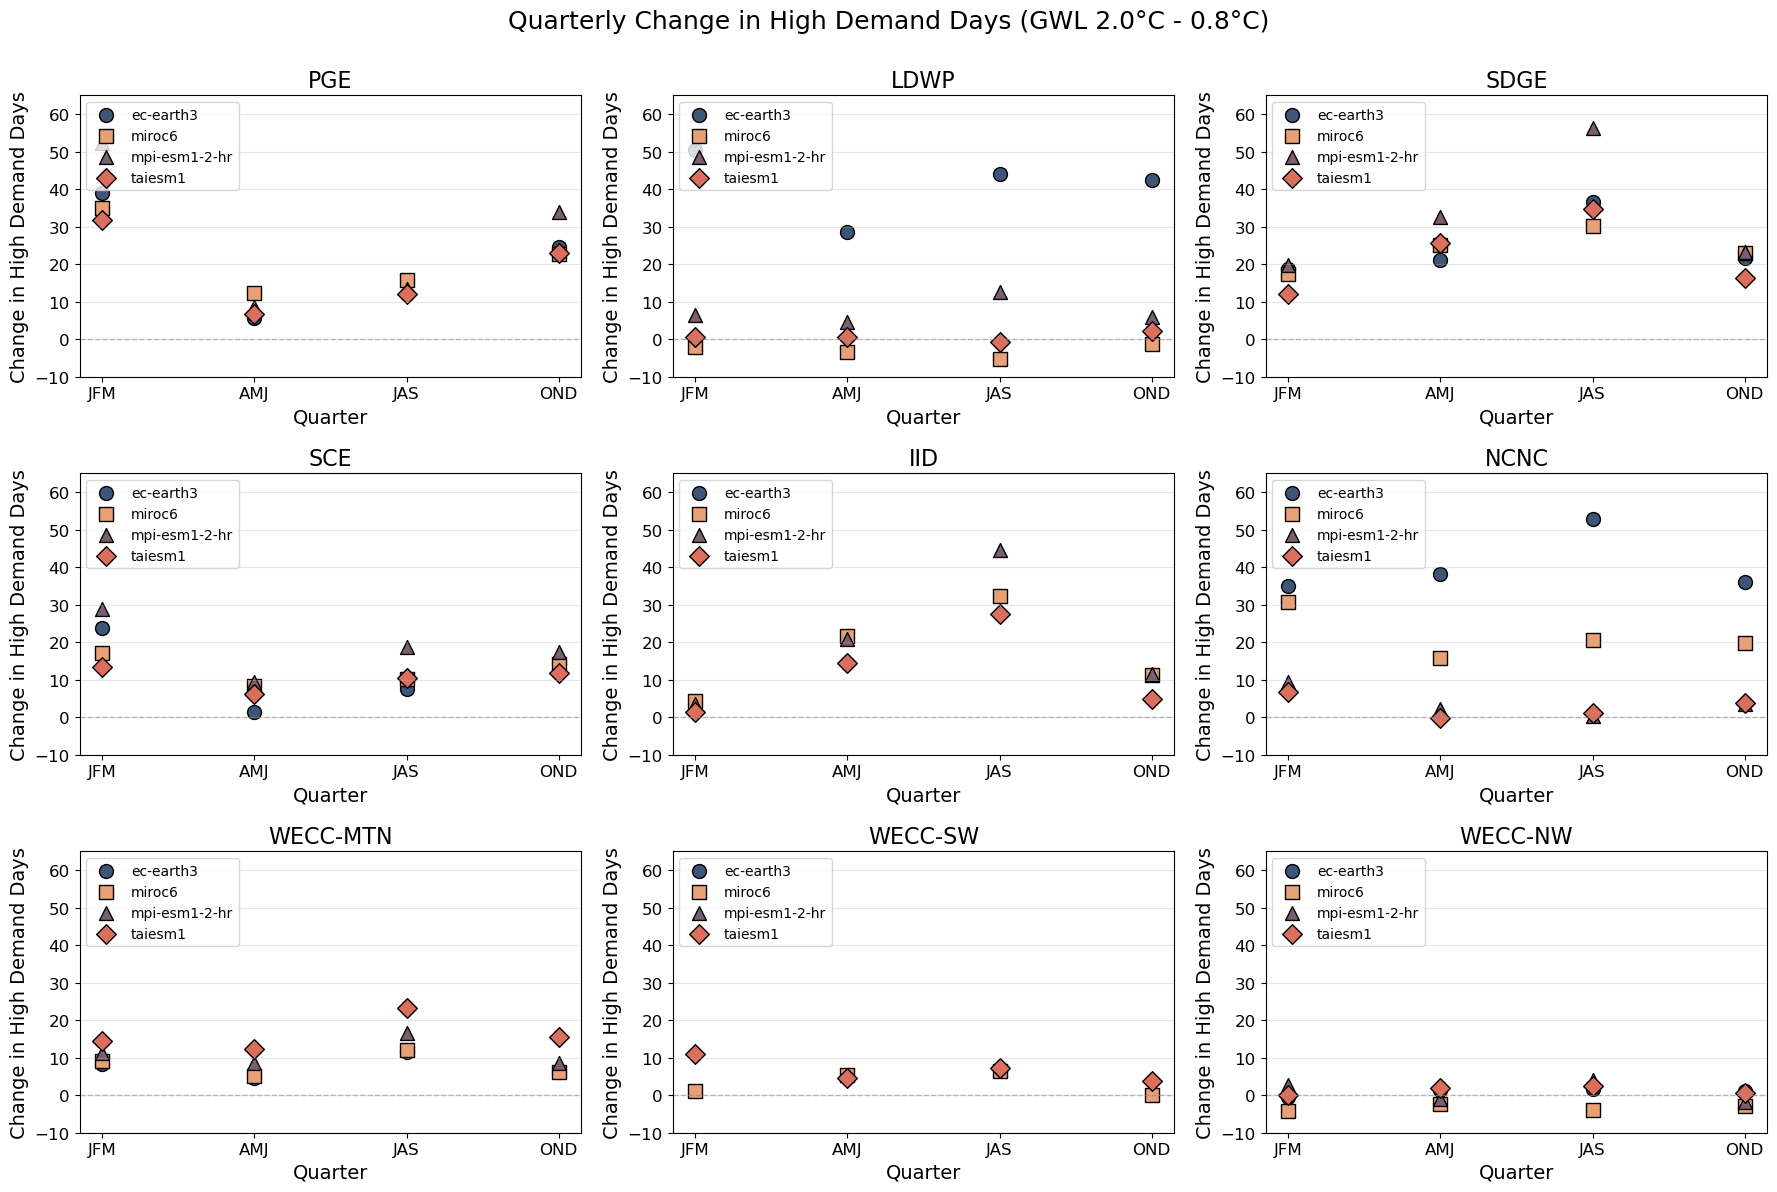

In [ ]:
# Plot quarterly changes in 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle('Quarterly Change in High Demand Days (GWL 2.0°C - 0.8°C)', fontsize=18, y=0.995)

# Quarter order for x-axis
quarters = ['JFM', 'AMJ', 'JAS', 'OND']
quarter_positions = {q: i for i, q in enumerate(quarters)}

# Plot each region
for i, region in enumerate(regions):
    ax = axes[i]
    
    # Plot each model
    for simulation in seasonal_changes.keys():
        change_data = seasonal_changes[simulation].sel(region=region)
        
        # Extract values for each quarter
        x_vals = []
        y_vals = []
        for quarter in quarters:
            if quarter in change_data.quarter.values:
                x_vals.append(quarter_positions[quarter])
                y_vals.append(float(change_data.sel(quarter=quarter).values))
        
        # Plot
        ax.scatter(x_vals, y_vals, 
                  label=simulation, 
                  marker=model_markers.get(simulation, 'o'),
                  color=model_colors.get(simulation, 'black'),
                  s=100, alpha=1, edgecolors='black', linewidth=1)
    
    # Add horizontal line at y=0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Formatting
    ax.set_xticks(range(len(quarters)))
    ax.set_xticklabels(quarters)
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Change in High Demand Days')
    ax.set_title(f'{region}')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(-10, 65)

plt.tight_layout()
plt.savefig('figures/quarterly_change_high_demand_days.png', dpi=400, bbox_inches='tight')
plt.show()